# HomeWork 3

In [224]:
import numpy as np
import matplotlib.pyplot as plt

In [225]:
def sigmoid(inp):
  return 1/(1+np.exp(-inp))

def grad_sigmoid(inp):
  return sigmoid(inp)*(1-sigmoid(inp))

In [226]:
def fwdPropagate(inputs, weights):
  W1, W2= weights

  a1 = np.dot(inputs, W1)
  z1 = sigmoid(a1)

  a2 = np.dot(z1, W2)
  output = sigmoid(a2)

  return [output,z1]

In [227]:
def loss(output, target):
  return np.mean((output-target)**2)

In [228]:
def backPropagate_upate(inputs, targets, weights,activations, learning_rate):

  output,z1=activations
  W1, W2= weights

  loss = np.mean((output-targets)**2)
  error_output=(output-targets)*grad_sigmoid(output)
  dj_dw2=np.dot(z1.T,error_output)/(len(inputs))

  error_hidden=np.dot(error_output,W2.T)*grad_sigmoid(z1)
  dj_dw1=np.dot(inputs.T,error_hidden)/(len(inputs))

  W1=W1-learning_rate*dj_dw1
  W2=W2-learning_rate*dj_dw2

  return [W1, W2]


In [229]:
def Deterministic_Gradient_Descent(inputs, targets, epochs, train_val_split, learning_rate):

  inputs_units=len(inputs[0])
  hidden_units =2
  output_units =1

  n_samples =len(inputs)

  index = int(train_val_split * n_samples)
  train_input, test_input = inputs[:index], inputs[index:]
  train_target, test_target = targets[:index], targets[index:]

  n_samples =len(train_input)

  #adding bais to hidden layer
  hidden_units+=1

  W1=np.random.rand(inputs_units,hidden_units)
  W2=np.random.rand(hidden_units,output_units)

  weights=[W1,W2]

  Train_loss=[]
  Test_loss=[]
  Train_acc=[]
  Test_acc=[]

  for epoch in range(epochs):
    shuffling = np.random.permutation(len(train_input))
    train_input = train_input[shuffling]
    train_target = train_target[shuffling]

    activations = fwdPropagate(train_input, weights)

    weights = backPropagate_upate(train_input, train_target, weights, activations, learning_rate)


    #Compute training accuracy, and training error
    train_output,z1 = fwdPropagate(train_input, weights)

    train_loss = loss(train_output, train_target)
    Train_loss.append(train_loss)

    count=0
    for i in range(len(train_output)):
      if(train_output[i]>0.5):
        train_output[i]=1
      else:
        train_output[i]=0

      if(train_output[i]==train_target[i]):
        count=count+1

    train_acc=count/len(train_output)
    Train_acc.append(train_acc)

    #Compute testing accuracy, and testing error
    test_output,z1 = fwdPropagate(test_input, weights)

    test_loss = loss(test_output, test_target)
    Test_loss.append(test_loss)

    count=0
    for i in range(len(test_output)):
      if(test_output[i]>0.5):
        test_output[i]=1
      else:
        test_output[i]=0

      if(test_output[i]==test_target[i]):
        count=count+1

    test_acc=count/len(test_output)
    Test_acc.append(test_acc)


  return weights,Train_loss,Test_loss,Train_acc,Test_acc

In [230]:
def Stochastic_Gradient_Descent(inputs, targets, batch_size, epochs, train_val_split, learning_rate):

  inputs_units=len(inputs[0])
  hidden_units =2
  output_units =1

  n_samples =len(inputs)

  index = int(train_val_split * n_samples)
  train_input, test_input = inputs[:index], inputs[index:]
  train_target, test_target = targets[:index], targets[index:]

  n_samples =len(train_input)
  n_batches =int(n_samples/batch_size)

  #adding bais
  hidden_units+=1

  W1=np.random.rand(inputs_units,hidden_units)
  W2=np.random.rand(hidden_units,output_units)

  weights=[W1,W2]

  Train_loss=[]
  Test_loss=[]
  Train_acc=[]
  Test_acc=[]

  for epoch in range(epochs):

    #Shuffle the training data
    shuffling = np.random.permutation(len(train_input))
    train_input_shuffle = train_input[shuffling]
    train_target_shuffle= train_target[shuffling]

    for batch in range(n_batches):

      start=batch*batch_size
      end=(batch+1)*batch_size

      train_batch=train_input_shuffle[start:end]
      target_batch=train_target_shuffle[start:end]

      activations = fwdPropagate(train_batch, weights)

      weights = backPropagate_upate(train_batch, target_batch, weights, activations, learning_rate)


    #Compute training accuracy, and training error
    train_output,z1 = fwdPropagate(train_input, weights)

    train_loss = loss(train_output,train_target)
    Train_loss.append(train_loss)

    count=0

    for i in range(len(train_output)):
      if(train_output[i]>0.5):
        train_output[i]=1
      else:
        train_output[i]=0

      if(train_output[i]==train_target[i]):
        count=count+1

    train_acc=count/len(train_output)
    Train_acc.append(train_acc)

    #Compute validation accuracy, and validation error
    test_output,z1 = fwdPropagate(test_input, weights)

    test_loss = loss(test_output,test_target)
    Test_loss.append(test_loss)

    count=0
    for i in range(len(test_output)):
      if(test_output[i]>0.5):
        test_output[i]=1
      else:
        test_output[i]=0

      if(test_output[i]==test_target[i]):
        count=count+1

    test_acc=count/len(test_output)
    Test_acc.append(test_acc)

  return weights,Train_loss,Test_loss,Train_acc,Test_acc

In [231]:
def plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate):
  weights,Train_loss,Test_loss,Train_acc,Test_acc=Deterministic_Gradient_Descent(inputs[:n], targets[:n], epochs, train_val_split, learning_rate)

  x=[i for i in range(1,len(Train_acc)+1)]

  plt.figure(figsize=(10, 5))
  plt.subplot(1,2,1)
  plt.plot(x,Train_loss,color='red',label="Training_loss")
  plt.plot(x,Test_loss,color='green',label="Testing_loss")
  plt.title(f"Loss Vs epochs for n={n}")
  plt.xlabel("epochs")
  plt.ylabel("Loss")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(x,Train_acc,color='red',label="Training_accuracy")
  plt.plot(x,Test_acc,color='green',label="Testing_accuracy")
  plt.title(f"Accuracy vs epochs for n={n}")
  plt.xlabel("epochs")
  plt.ylabel("accuracy")
  plt.legend()

  plt.tight_layout()
  plt.show()

  print("Training loss :",Train_loss[-1])
  print("Testing loss :",Test_loss[-1])
  print("Training accuracy :",Train_acc[-1])
  print("Testing accuracy :",Test_acc[-1])



In [232]:
def plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate):
  weights,Train_loss,Test_loss,Train_acc,Test_acc=Stochastic_Gradient_Descent(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

  x =[i for i in range(1,len(Train_acc)+1)]

  plt.figure(figsize=(10, 5))
  plt.subplot(1,2,1)
  plt.plot(x,Train_loss,color='red',label="Training_loss")
  plt.plot(x,Test_loss,color='green',label="Testing_loss")
  plt.title(f"Loss Vs epochs for batch_size={batch_size}")
  plt.xlabel("epochs")
  plt.ylabel("Loss")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(x,Train_acc,color='red',label="Training_accuracy")
  plt.plot(x,Test_acc,color='green',label="Testing_accuracy")
  plt.title(f"Accuracy vs epochs for batch_size={batch_size}")
  plt.xlabel("epochs")
  plt.ylabel("accuracy")
  plt.legend()

  plt.tight_layout()
  plt.show()

  print("Training loss :",Train_loss[-1])
  print("Testing loss :",Test_loss[-1])
  print("Training accuracy :",Train_acc[-1])
  print("Testing accuracy :",Test_acc[-1])


# XOR

In [242]:
#data
input=[[0,0],[0,1],[1,0],[1,1]]
target=[0,1,1,0]

# Generating 600 datapoints
inputs=[]
targets=[]
for i in range(150):
  inputs=inputs+input
  targets=targets+target

inputs=np.array(inputs)
targets=np.array(targets)

noise = np.random.normal(0, 0.1, inputs.shape)
inputs_noisy = inputs + noise

# adding 1 bias to each inputs
bias = np.ones((inputs_noisy.shape[0], 1))
inputs = np.hstack(( bias,inputs_noisy))
targets=targets.reshape(-1,1)



(a)Deterministic Gradient Descent

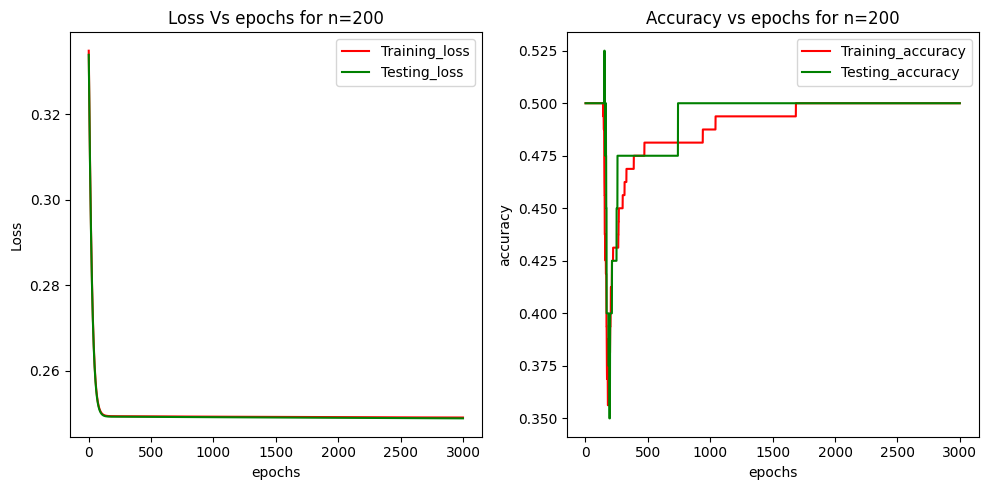

Training loss : 0.24911855238725575
Testing loss : 0.2489264472694937
Training accuracy : 0.5
Testing accuracy : 0.5


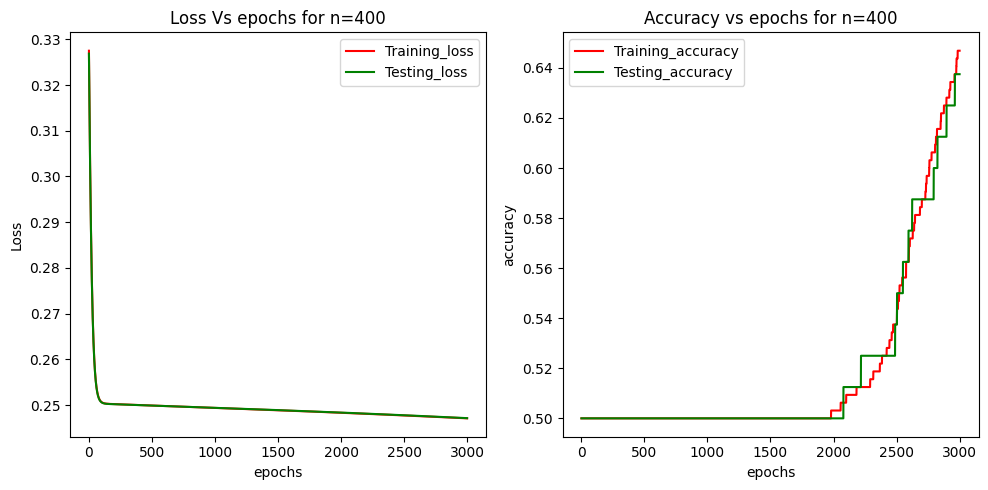

Training loss : 0.24708467285456762
Testing loss : 0.24712773628164192
Training accuracy : 0.646875
Testing accuracy : 0.6375


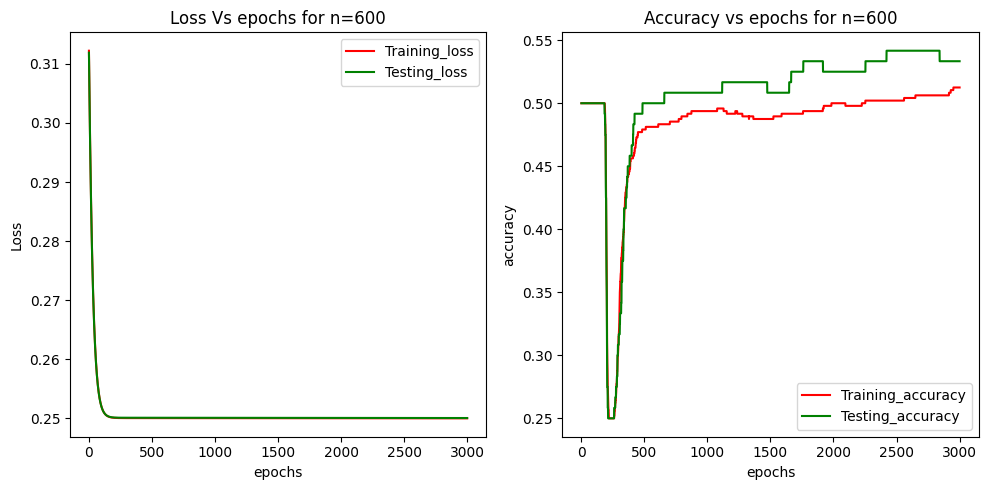

Training loss : 0.24996435919484555
Testing loss : 0.2500178507109959
Training accuracy : 0.5125
Testing accuracy : 0.5333333333333333


In [234]:
epochs=3000
train_val_split=0.8
learning_rate=0.3

n=200
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

n=400
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

n=600
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

(b)Stochastic Gradient Descent

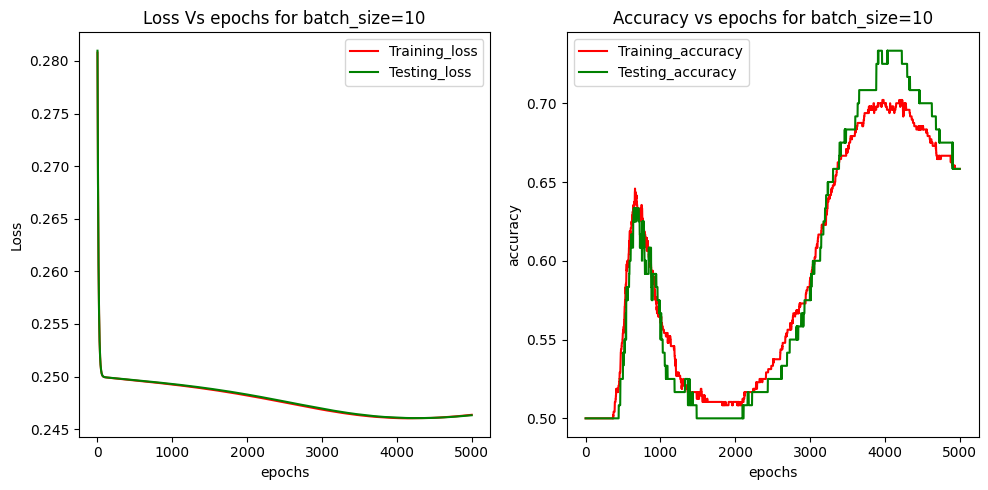

Training loss : 0.24636895220784594
Testing loss : 0.24632767534640315
Training accuracy : 0.6583333333333333
Testing accuracy : 0.6583333333333333


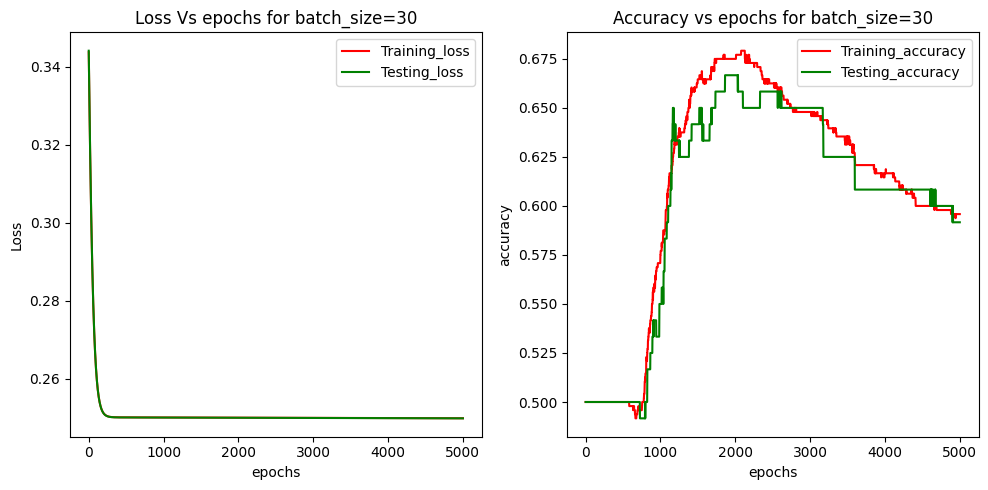

Training loss : 0.24993048252609923
Testing loss : 0.24991199465384836
Training accuracy : 0.5958333333333333
Testing accuracy : 0.5916666666666667


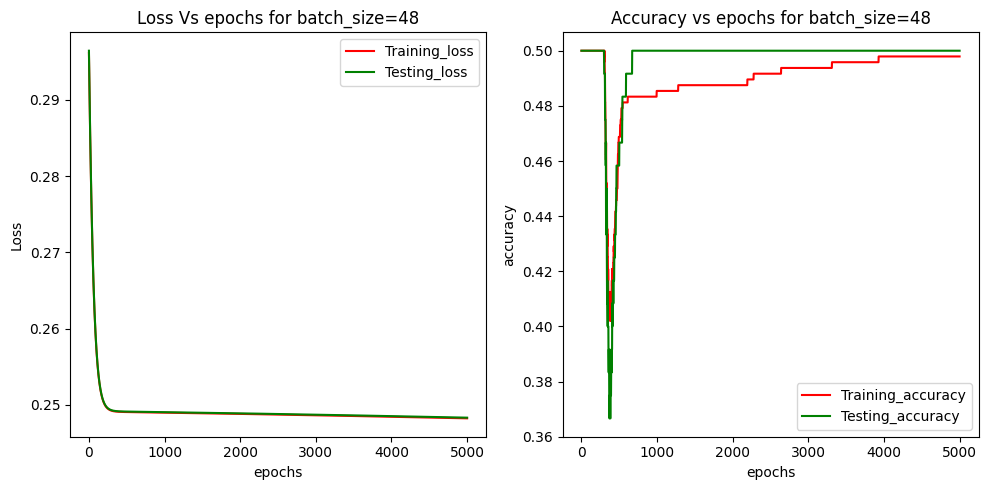

Training loss : 0.24821491172866533
Testing loss : 0.24830383420720617
Training accuracy : 0.4979166666666667
Testing accuracy : 0.5


In [245]:
epochs=5000
train_val_split=0.8
learning_rate=0.01

batch_size=10
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

batch_size=30
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

batch_size=48
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

# AND

In [236]:
#data
input=[[0,0],[0,1],[1,0],[1,1]]
target=[0,0,0,1]

# Generating 600 datapoints
inputs=[]
targets=[]
for i in range(150):
  inputs=inputs+input
  targets=targets+target

inputs=np.array(inputs)
targets=np.array(targets)

noise = np.random.normal(0, 0.1, inputs.shape)
inputs_noisy = inputs + noise

# adding 1 bias to each inputs
bias = np.ones((inputs_noisy.shape[0], 1))
inputs = np.hstack(( bias,inputs_noisy))
targets=targets.reshape(-1,1)


(a)Deterministic Gradient Descent

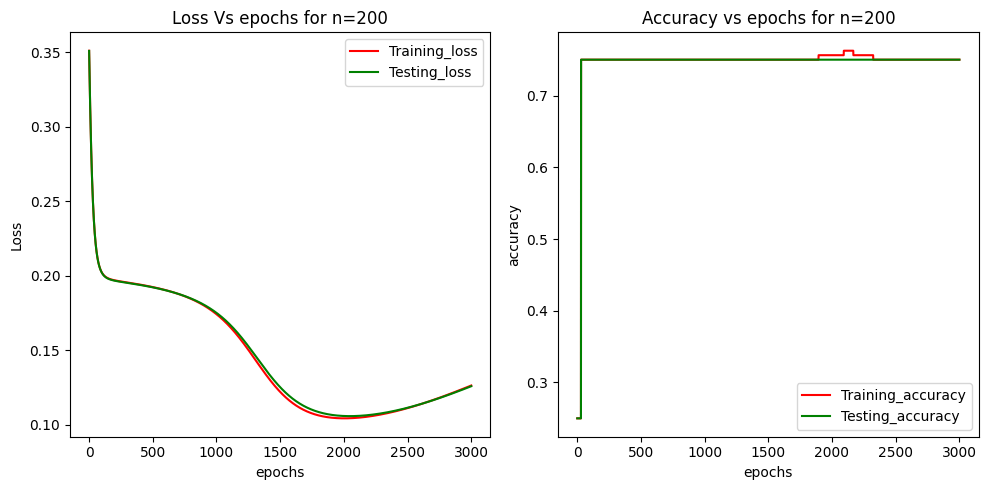

Training loss : 0.12626812592401832
Testing loss : 0.12578624620226692
Training accuracy : 0.75
Testing accuracy : 0.75


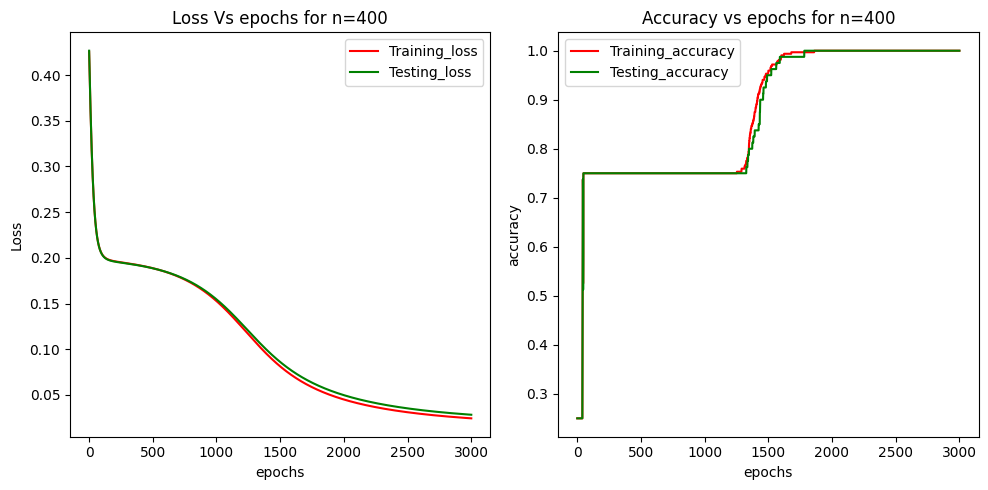

Training loss : 0.024316475321936905
Testing loss : 0.02825775058072706
Training accuracy : 1.0
Testing accuracy : 1.0


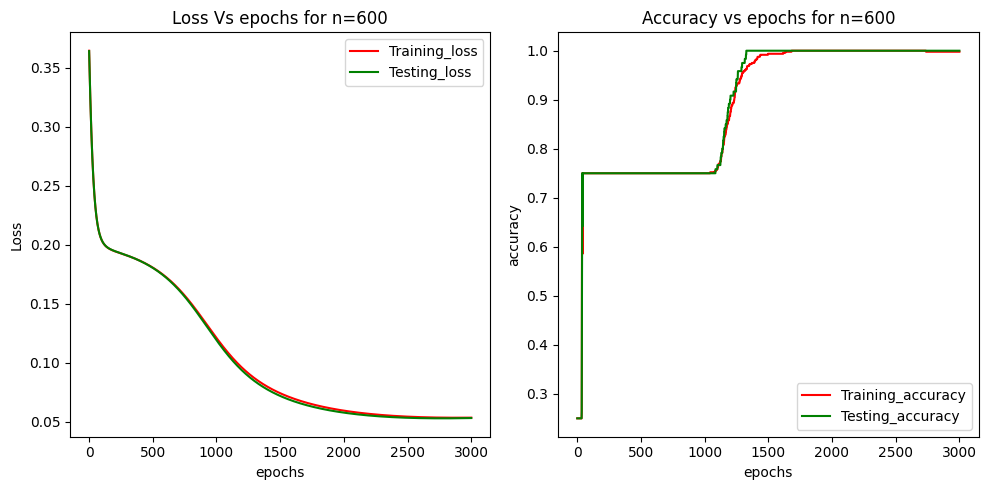

Training loss : 0.05353888976932088
Testing loss : 0.05321275596312325
Training accuracy : 0.9979166666666667
Testing accuracy : 1.0


In [237]:
epochs=3000
train_val_split=0.8
learning_rate=0.2

n=200
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

n=400
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

n=600
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

(b)Stochastic Gradient Descent

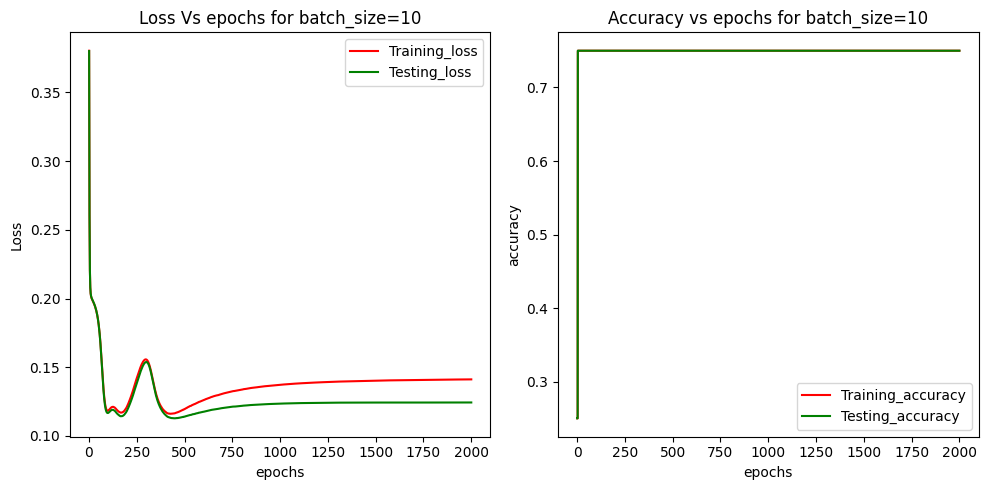

Training loss : 0.1411333292914114
Testing loss : 0.1243208965000668
Training accuracy : 0.75
Testing accuracy : 0.75


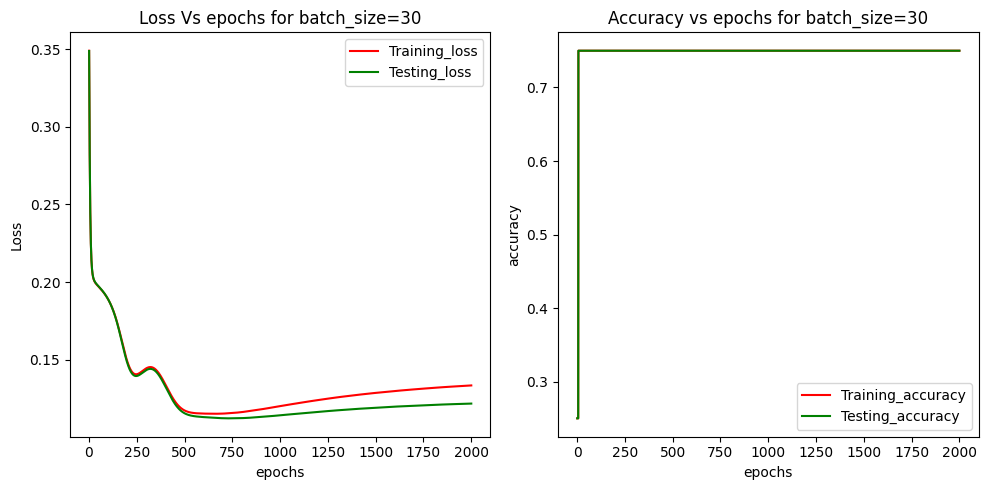

Training loss : 0.13343160283907501
Testing loss : 0.12174862756023339
Training accuracy : 0.75
Testing accuracy : 0.75


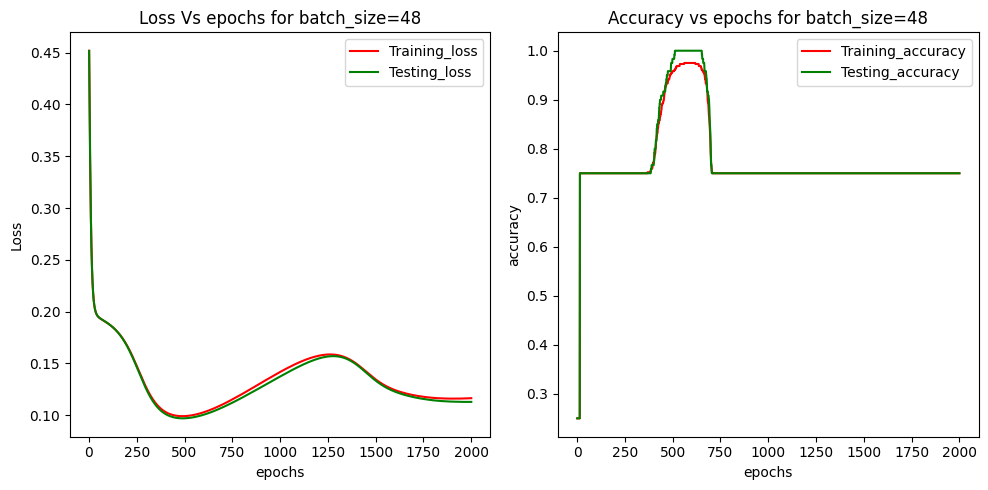

Training loss : 0.11631508245584439
Testing loss : 0.11273164687986813
Training accuracy : 0.75
Testing accuracy : 0.75


In [238]:
epochs=2000
train_val_split=0.8
learning_rate=0.08

batch_size=10
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

batch_size=30
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

batch_size=48
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

# OR

In [239]:
#data
input=[[0,0],[0,1],[1,0],[1,1]]
target=[0,1,1,1]

# Generating 600 datapoints
inputs=[]
targets=[]
for i in range(150):
  inputs=inputs+input
  targets=targets+target

inputs=np.array(inputs)
targets=np.array(targets)

noise = np.random.normal(0, 0.1, inputs.shape)
inputs_noisy = inputs + noise

# adding 1 bias to each inputs
bias = np.ones((inputs_noisy.shape[0], 1))
inputs = np.hstack(( bias,inputs_noisy))
targets=targets.reshape(-1,1)

(a)Deterministic Gradient Descent

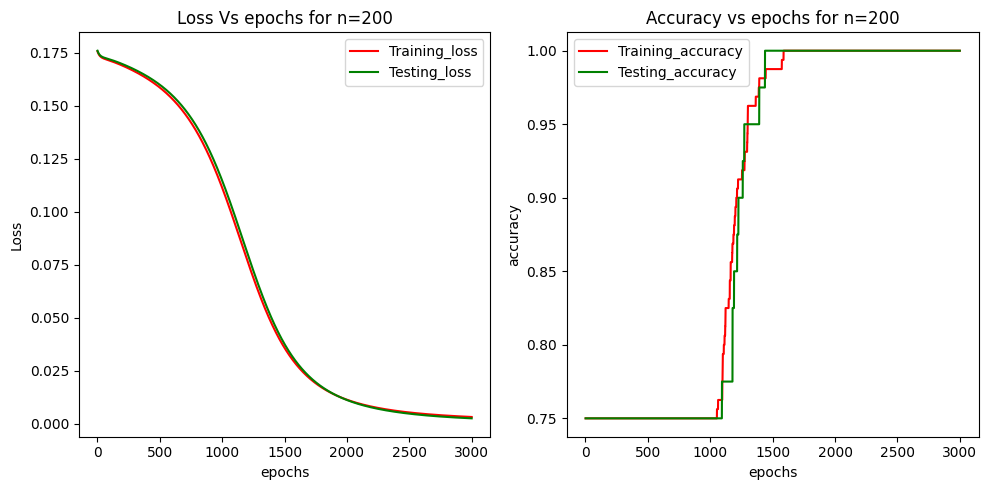

Training loss : 0.003137083805233411
Testing loss : 0.002489359959470464
Training accuracy : 1.0
Testing accuracy : 1.0


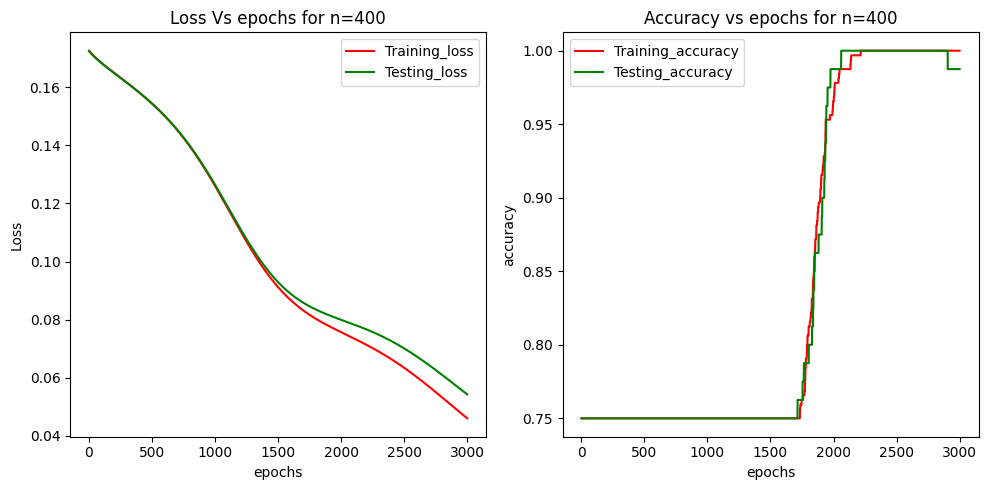

Training loss : 0.04604997104861316
Testing loss : 0.054309714922547145
Training accuracy : 1.0
Testing accuracy : 0.9875


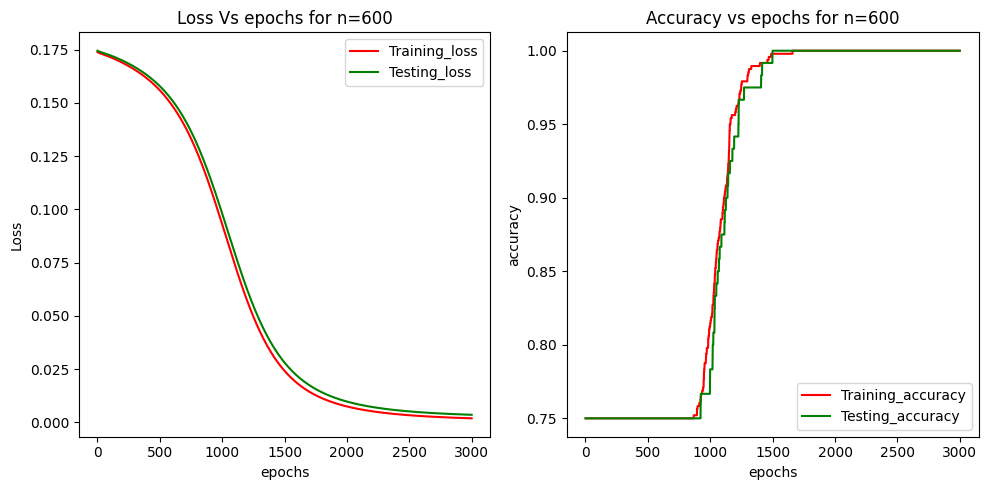

Training loss : 0.00194500293483751
Testing loss : 0.0036089071245916557
Training accuracy : 1.0
Testing accuracy : 1.0


In [240]:
epochs=3000
train_val_split=0.8
learning_rate=0.3

n=200
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

n=400
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

n=600
plot_deterministic(n,inputs, targets, epochs, train_val_split, learning_rate)

(b)Stochastic Gradient Descent

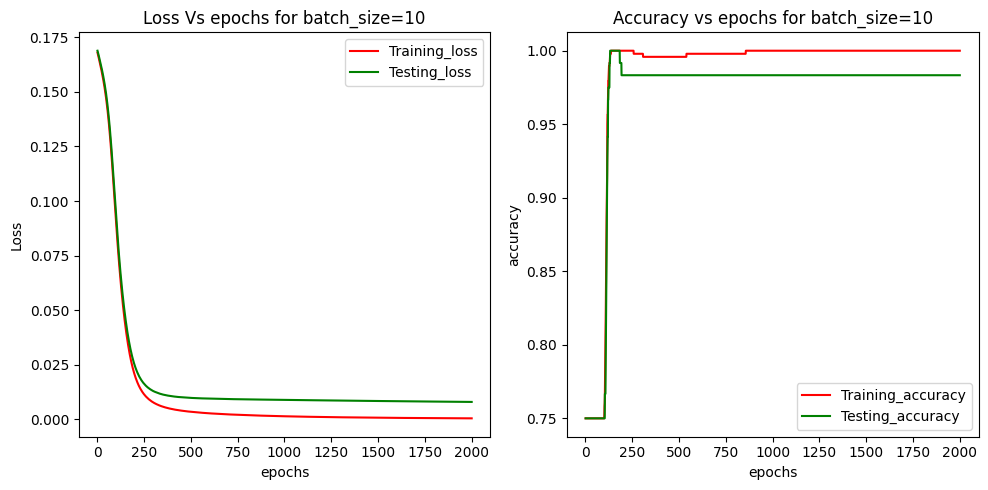

Training loss : 0.0003860152787516001
Testing loss : 0.007909120922141155
Training accuracy : 1.0
Testing accuracy : 0.9833333333333333


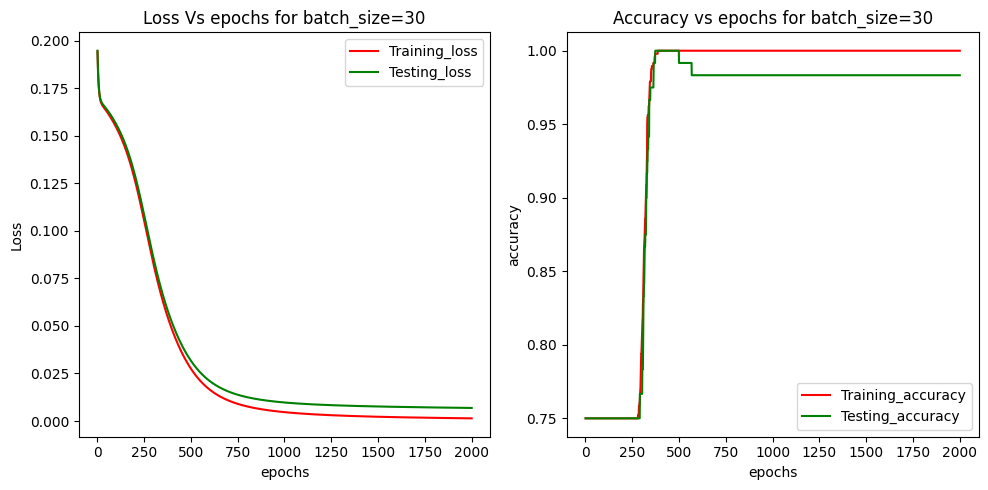

Training loss : 0.0014073944972283906
Testing loss : 0.006871712628643135
Training accuracy : 1.0
Testing accuracy : 0.9833333333333333


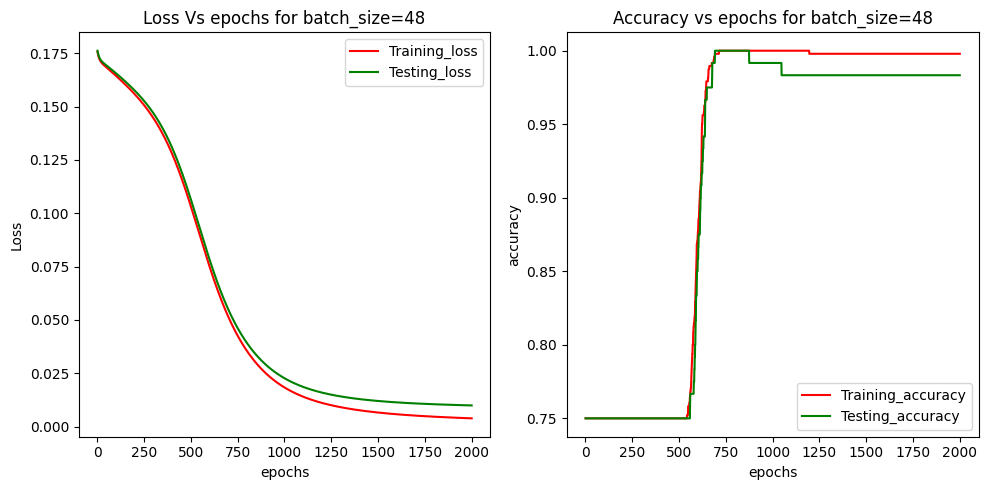

Training loss : 0.0038888057003001694
Testing loss : 0.009940453865857395
Training accuracy : 0.9979166666666667
Testing accuracy : 0.9833333333333333


In [241]:
epochs=2000
train_val_split=0.8
learning_rate=0.08

batch_size=10
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

batch_size=30
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)

batch_size=48
plot_Stochastic(inputs, targets, batch_size, epochs, train_val_split, learning_rate)